In [1]:
import numpy as np
from scipy.special import ndtr
from scipy.optimize import minimize, Bounds
import matplotlib.pyplot as plt
from numpy.polynomial.hermite import hermfit, hermval, hermder

In [2]:


R_1Y, R_18M, R_2Y = 0.02815, 0.029152, 0.02966

p_1Y = 1/(1+R_1Y)
p_1_5Y = (1 - R_18M*1.0*p_1Y) / (1 + R_18M*0.5)
p_2Y = (1 - R_2Y*p_1Y) / (1 + R_2Y)

alpha = 0.5
S_swap = alpha*p_1_5Y + alpha*p_2Y
R_swap = (p_1Y - p_2Y) / S_swap

#K_swaption_offset = [-200, -100, -50, -25, 0, 25, 50, 100, 200]
#iv_market = np.array([0.3255, 0.2443, 0.2187, 0.2103, 0.2050, 0.2023, 0.2022, 0.2073, 0.2260])

K_swaption_offset = [-200, -100, -50, -25, 0, 25, 50, 100, 200]
iv_market = np.array([0.3255, 0.2443, 0.2187, 0.2103, 0.2050, 0.2023, 0.2022, 0.2073, 0.2260])
T_exp = 1.0

K = R_swap + np.array(K_swaption_offset)/10000

print(f"p(1Y)={p_1Y:.5f}, p(1.5Y)={p_1_5Y:.5f}, p(2Y)={p_2Y:.5f}")
print(f"S_swap={S_swap:.5f}, R_swap={R_swap:.5f}")

#K_swaption_offset = [-200, -100, -50, -25, 0, 25, 50, 100, 200]
#iv_market = np.array([0.3255, 0.2443, 0.2187, 0.2103, 0.2050, 0.2023, 0.2022, 0.2073, 0.2260])
#K = R_swap + np.array(K_swaption_offset)/10000

def fit_sabr_obj(param,sigma_market,K,T,R):
    sigma_0, beta, upsilon, rho = param
    N = len(sigma_market)
    sse = 0
    for n in range(0,N):
        sigma_model = sigma_sabr(K[n],T,R,sigma_0,beta,upsilon,rho)
        sse += (sigma_market[n]-sigma_model)**2
    return sse

def sigma_sabr(K,T,F_0,sigma_0,beta,upsilon,rho):

    """ 
    Here F_0 = swap curve derived using swap_rate_from_zcb_prices
    Sigma normally found using min. function
    """
    if abs(F_0-K) < 1e-8:    # SABR ATM formula
        sigma = sigma_0*F_0**(beta-1)*(1+(((1-beta)**2/24)*(sigma_0**2*(F_0)**(2*beta-2)) + (rho*beta*upsilon*sigma_0/4)*(F_0)**(beta-1) + (2-3*rho**2)/24*upsilon**2)*T)
    else:
        z = (upsilon/sigma_0)*(F_0*K)**((1-beta)/2)*np.log(F_0/K)
        x = np.log((np.sqrt(1-2*rho*z+z**2) + z - rho)/(1-rho))
        D = (F_0*K)**((1-beta)/(2))*(1 + ((1-beta)**2/24)*np.log2(F_0/K) + ((1-beta)**4/1920)*np.emath.logn(4,F_0/K))
        A = 1 + (((1-beta)**2/24)*sigma_0**2*(F_0*K)**(beta-1) + (rho*beta*upsilon*sigma_0/4)*(F_0*K)**((beta-1)/2) + ((2-3*rho**2)/24)*upsilon**2)*T
        sigma = (sigma_0/D)*(z/x)*A
    return sigma

def black_swaption_price(sigma,T,K,S,R,type_option = "call"):
    # sigma := The volatility parameter
    # T     := Time to maturity
    # K     := p_strike
    # S     := Accrual factor
    # R     := forward par swap rate (Underlying asset)
    d1 = (np.log(R/K) + 0.5*sigma**2*T)/(sigma*np.sqrt(T))
    d2 = (np.log(R/K) - 0.5*sigma**2*T)/(sigma*np.sqrt(T))
    if type_option == 'put':
        price = S*(K*ndtr(-d2) - R*ndtr(-d1))
    else:
        price = S*(R*ndtr(d1) - K*ndtr(d2))
    return price 


# --- SABR fit, beta bounded to [0,1] to keep the model economically valid ---
bounds = Bounds([1e-4, 0.0, 1e-4, -0.999], [np.inf, 1.0, np.inf, 0.999])
param_0 = 0.20, 0.5, 0.40, -0.20
result = minimize(fit_sabr_obj, param_0, method='L-BFGS-B', bounds=bounds,
                   args=(iv_market, K, T_exp, R_swap),
                   options={'maxiter': 20000, 'ftol': 1e-14, 'gtol': 1e-12})
sigma_0, beta, upsilon, rho = result.x
print(f"\nSABR fit: sigma_0={sigma_0:.5f}, beta={beta:.5f}, upsilon={upsilon:.5f}, rho={rho:.5f}, sse={result.fun:.3e}")

iv_fit = np.array([sigma_sabr(K[i], T_exp, R_swap, sigma_0, beta, upsilon, rho) for i in range(len(K))])
iv_flat_black = np.full_like(iv_market, iv_market[4])  # flat ATM vol applied to all strikes

print("\nOffset(bp)  Market IV   SABR fit   Flat Black   SABR err(bp)  Flat err(bp)")
for i in range(len(K)):
    print(f"{K_swaption_offset[i]:>9}   {iv_market[i]*100:>7.3f}%   {iv_fit[i]*100:>7.3f}%   {iv_flat_black[i]*100:>7.3f}%   "
          f"{(iv_fit[i]-iv_market[i])*10000:>9.2f}   {(iv_flat_black[i]-iv_market[i])*10000:>9.2f}")

p(1Y)=0.97262, p(1.5Y)=0.95769, p(2Y)=0.94318
S_swap=0.95043, R_swap=0.03098

SABR fit: sigma_0=0.20296, beta=1.00000, upsilon=0.46987, rho=-0.18059, sse=1.590e-05

Offset(bp)  Market IV   SABR fit   Flat Black   SABR err(bp)  Flat err(bp)
     -200    32.550%    32.700%    20.500%       15.03    -1205.00
     -100    24.430%    24.147%    20.500%      -28.35     -393.00
      -50    21.870%    21.796%    20.500%       -7.37     -137.00
      -25    21.030%    21.042%    20.500%        1.22      -53.00
        0    20.500%    20.563%    20.500%        6.33        0.00
       25    20.230%    20.338%    20.500%       10.83       27.00
       50    20.220%    20.329%    20.500%       10.93       28.00
      100    20.730%    20.770%    20.500%        3.97      -23.00
      200    22.600%    22.454%    20.500%      -14.57     -210.00


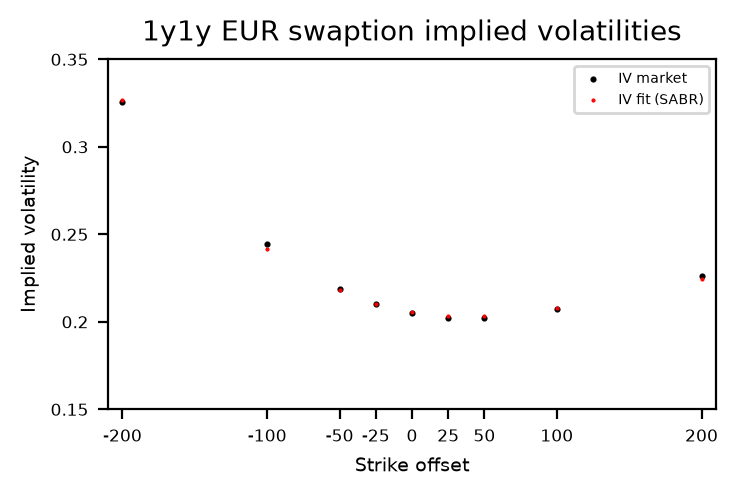

In [3]:

# Plot of market vs SABR-fit implied volatilities
fig = plt.figure(constrained_layout=False, dpi=200, figsize=(4,2.5))
fig.suptitle(f"1y1y EUR swaption implied volatilities", fontsize=10)
gs = fig.add_gridspec(nrows=1, ncols=1, left=0.12, bottom=0.2, right=0.88, top=0.90, wspace=0, hspace=0)
ax = fig.add_subplot(gs[0,0])
xticks = K_swaption_offset
ax.set_xticks(xticks)
ax.set_xticklabels(xticks, fontsize=6)
ax.set_xlim([xticks[0]-10, xticks[-1]+10])
plt.xlabel(f"Strike offset", fontsize=7)
yticks = [0.15, 0.20, 0.25, 0.30, 0.35]
ax.set_yticks(yticks)
ax.set_yticklabels(yticks, fontsize=6)
ax.set_ylim([0.15, 0.35])
ax.set_ylabel(f"Implied volatility", fontsize=7)
plt.grid(axis='y', which='major', color=(0.7,0.7,0.7,0), linestyle='--')
p1 = ax.scatter(K_swaption_offset, iv_market, s=6, color='black', marker=".", label="IV market")
p2 = ax.scatter(K_swaption_offset, iv_fit, s=1, color='red', marker=".", label="IV fit (SABR)")
plots = [p1, p2]
labels = [item.get_label() for item in plots]
ax.legend(plots, labels, loc="upper right", fontsize=5)
plt.show()

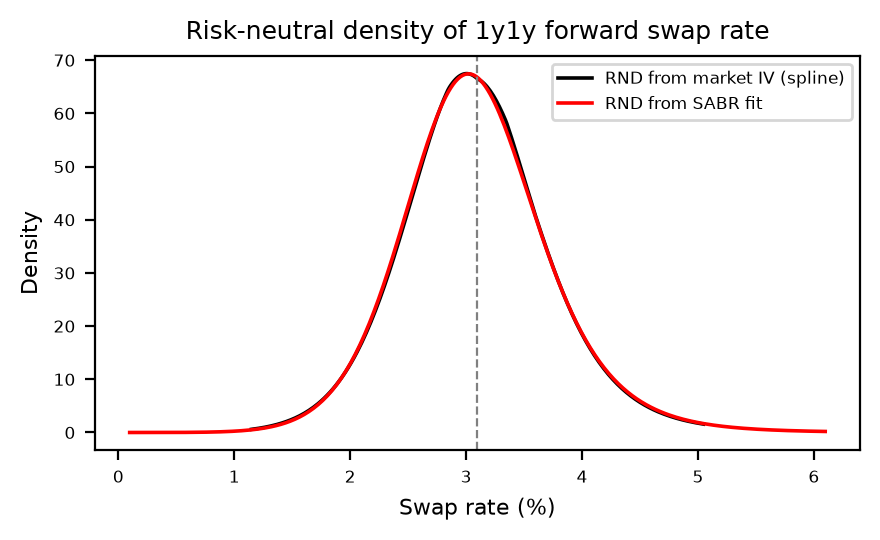

In [4]:
import numpy as np
from scipy.special import ndtr
from scipy.optimize import minimize, Bounds
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt



# --- Market smile interpolation (cubic spline in strike) ---
spline_iv = CubicSpline(K, iv_market)    

def price_market_interp(K):
    sig = spline_iv(K)
    return black_swaption_price(sig, T_exp, K, S_swap, R_swap)

def price_sabr(K):
    K = np.atleast_1d(K)
    sig = np.array([sigma_sabr(k, T_exp, R_swap, sigma_0, beta, upsilon, rho) for k in K])
    price = black_swaption_price(sig, T_exp, K, S_swap, R_swap)
    return price if price.size > 1 else price[0]

# --- Breeden-Litzenberger for swaptions
def rnd(price_fn, K, dK=1e-4):
    return (price_fn(K-dK) + price_fn(K+dK) - 2*price_fn(K)) / dK**2 / S_swap

K_min, K_max = K.min(), K.max()
K_grid_market = np.linspace(K_min+0.0005, K_max-0.0005, 300)   # stay inside spline's domain
K_grid_sabr   = np.linspace(K_min-0.01, K_max+0.01, 300)       # SABR extrapolates further safely

f_market = rnd(price_market_interp, K_grid_market)
f_sabr   = rnd(price_sabr, K_grid_sabr)

# Plot
fig = plt.figure(dpi=200, figsize=(4.5,2.8))
ax = fig.add_subplot(111)
ax.plot(K_grid_market*100, f_market, color='black', lw=1.3, label="RND from market IV (spline)")
ax.plot(K_grid_sabr*100, f_sabr, color='red', lw=1.3, label="RND from SABR fit")
ax.axvline(R_swap*100, color='grey', ls='--', lw=0.8)
ax.set_xlabel("Swap rate (%)", fontsize=8)
ax.set_ylabel("Density", fontsize=8)
ax.set_title("Risk-neutral density of 1y1y forward swap rate", fontsize=9)
ax.tick_params(labelsize=6)
ax.legend(fontsize=6)
plt.tight_layout()
plt.show()

MC mean F(T): 0.03090 (should match R_swap=0.03098)


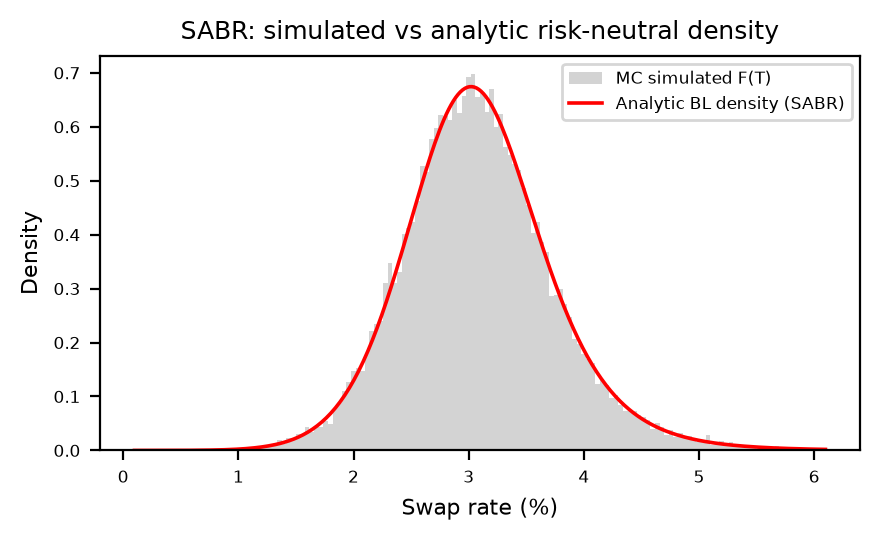

In [5]:
def sabr_simul(F_0,sigma_0,beta,upsilon,rho,M,T,method = "euler"):
    sigma, F = np.zeros([M+1]), np.zeros([M+1])
    sigma[0], F[0] = sigma_0, F_0
    delta = T/M
    Z = np.random.standard_normal([2,M])
    delta_sqrt = np.sqrt(delta)
    rho_sqrt_help = np.sqrt(1-rho**2)
    if method == "euler":
        for m in range(1,M+1):
            F[m] = F[m-1] + sigma[m-1]*F[m-1]**beta*delta_sqrt*Z[0,m-1]
            if F[m] <= 0:
                F[m] = F[m-1]
            sigma[m] = sigma[m-1] + upsilon*sigma[m-1]*delta_sqrt*(rho*Z[0,m-1] + rho_sqrt_help*Z[1,m-1])
    return F, sigma

def price_sabr(Kx):
    Kx = np.atleast_1d(Kx)
    sig = np.array([sigma_sabr(k, T_exp, R_swap, sigma_0, beta, upsilon, rho) for k in Kx])
    return black_swaption_price(sig, T_exp, Kx, S_swap, R_swap)

def rnd_sabr(Kx, dK=1e-4):
    return (price_sabr(Kx-dK) + price_sabr(Kx+dK) - 2*price_sabr(Kx)) / dK**2 / S_swap

# --- Monte Carlo: simulate many terminal F(T) paths ---
np.random.seed(7)
N_paths = 20000
M_steps = 1000
F_terminal = np.zeros(N_paths)
for n in range(N_paths):
    F_path, _ = sabr_simul(R_swap, sigma_0, beta, upsilon, rho, M_steps, T_exp)
    F_terminal[n] = F_path[-1]

print(f"MC mean F(T): {F_terminal.mean():.5f} (should match R_swap={R_swap:.5f})")

# --- Plot: MC histogram vs analytic BL density (built earlier from sigma_sabr + finite differences) ---
import matplotlib.pyplot as plt
K_grid = np.linspace(max(1e-4, R_swap-0.03), R_swap+0.03, 300)
f_analytic = rnd_sabr(K_grid)   # from your earlier BL-on-SABR function

fig = plt.figure(dpi=200, figsize=(4.5,2.8))
ax = fig.add_subplot(111)
ax.hist(F_terminal*100, bins=150, range=(K_grid[0]*100, K_grid[-1]*100), density=True, color='lightgrey', label="MC simulated F(T)")
ax.plot(K_grid*100, f_analytic/100, color='red', lw=1.3, label="Analytic BL density (SABR)")  # /100: match %-axis units
ax.set_xlabel("Swap rate (%)", fontsize=8)
ax.set_ylabel("Density", fontsize=8)
ax.set_title("SABR: simulated vs analytic risk-neutral density", fontsize=9)
ax.tick_params(labelsize=6)
ax.legend(fontsize=6)
plt.tight_layout()
plt.show()

## Function

In [6]:
def swaption_rnd(T_ois, p_ois, idx_exer, idx_mat, alpha, offsets_bps, iv_market, T_exp,
                  n_grid=300, dK=1e-4, sabr_x0=(0.20, 0.5, 0.40, -0.20)):
    """
    Build the risk-neutral density of a forward swap rate (one expiry x tenor cell)
    from an ALREADY-BUILT discount curve (T_ois, p_ois -- e.g. from build_ois_curve)
    and a Black-vol smile, both from the market and from a SABR fit.
    """
    T_ois = np.asarray(T_ois, dtype=float)
    p_ois = np.asarray(p_ois, dtype=float)
    offsets_bps = np.asarray(offsets_bps, dtype=float)
    iv_market = np.asarray(iv_market, dtype=float)

    S_swap = 0.0
    for i in range(idx_exer+1, idx_mat+1):
        S_swap += alpha*p_ois[i]
    R_swap = (p_ois[idx_exer] - p_ois[idx_mat]) / S_swap

    K = R_swap + offsets_bps/10000

    bounds = Bounds([1e-4, 0.0, 1e-4, -0.999], [np.inf, 1.0, np.inf, 0.999])
    result = minimize(fit_sabr_obj, list(sabr_x0), method='L-BFGS-B', bounds=bounds,
                       args=(iv_market, K, T_exp, R_swap),
                       options={'maxiter': 20000, 'ftol': 1e-14, 'gtol': 1e-12})
    sigma_0, beta, upsilon, rho = result.x

    spline_iv = CubicSpline(K, iv_market)

    def price_market_interp(Kx):
        return black_swaption_price(spline_iv(Kx), T_exp, Kx, S_swap, R_swap)

    def price_sabr(Kx):
        Kx = np.atleast_1d(Kx)
        sig = np.array([sigma_sabr(k, T_exp, R_swap, sigma_0, beta, upsilon, rho) for k in Kx])
        pr = black_swaption_price(sig, T_exp, Kx, S_swap, R_swap)
        return pr if pr.size > 1 else pr[0]

    def rnd(price_fn, Kx, dKx=dK):
        return (price_fn(Kx-dKx) + price_fn(Kx+dKx) - 2*price_fn(Kx)) / dKx**2 / S_swap

    K_min, K_max = K.min(), K.max()
    K_grid_market = np.linspace(K_min+5*dK, K_max-5*dK, n_grid)
    K_grid_sabr   = np.linspace(K_min-0.01, K_max+0.01, n_grid)

    f_market = rnd(price_market_interp, K_grid_market)
    f_sabr   = rnd(price_sabr, K_grid_sabr)

    return {"S_swap": S_swap, "R_swap": R_swap, "K": K,
            "sabr_params": {"sigma_0": sigma_0, "beta": beta, "upsilon": upsilon, "rho": rho},
            "sabr_fit_result": result,
            "K_grid_market": K_grid_market, "f_market": f_market,
            "K_grid_sabr": K_grid_sabr, "f_sabr": f_sabr}

In [16]:
def spot_rates_from_zcb_prices(T,p,method = "continuous"):
    M = len(T)
    R = np.zeros([M])
    if method == "continuous":
        for i in range(0,M):
            if T[i] < 1e-10:
                R[i] = np.nan
            else:
                R[i] = -np.log(p[i])/T[i]
    elif method == "simple":
        for i in range(0,M):
            if T[i] < 1e-10:
                R[i] = np.nan
            else:
                R[i] = (1-p[i])/(T[i]*p[i])
    elif method == "discrete":
        for i in range(0,M):
            if T[i] < 1e-10:
                R[i] = np.nan
            else:
                R[i] = p[i]**(-1/T[i]) - 1
    return R

def zcb_curve_interpolate(T_inter,T,R,interpolation_options = {"method":"linear"}):
    N = len(T_inter)
    p_inter = np.ones([N])
    R_inter = np.zeros([N])
    f_inter = np.zeros([N])
    R_inter, R_inter_deriv = interpolate(T_inter,T,R,interpolation_options = interpolation_options)
    for i in range(0,N):
        f_inter[i] = R_inter[i] + R_inter_deriv[i]*T_inter[i]
        p_inter[i] = np.exp(-R_inter[i]*T_inter[i])
    return p_inter, R_inter, f_inter, T_inter


def extrapolate(x_extra,x,y,extrapolation_options = {"method":"linear"}):
    # Extrapoltion of value corresponding to a choice of x_extra
    if extrapolation_options["method"] == "linear":
        if x_extra < x[0]:
            a = (y[1]-y[0])/(x[1]-x[0])
            b = y[0]-a*x[0]
            y_extra = a*x_extra + b
            y_extra_deriv = a
        elif x[-1] < x_extra:
            a = (y[-1]-y[-2])/(x[-1]-x[-2])
            b = y[-1]-a*x[-1]
            y_extra = a*x_extra + b
            y_extra_deriv = a
        else:
            print(f"WARNING! x_extra is inside the dataset")
    elif extrapolation_options["method"] == "hermite":
        if x_extra < x[0]:
            coefs = hermfit(x[0:extrapolation_options["degree"]+1],y[0:extrapolation_options["degree"]+1],extrapolation_options["degree"])
            y_extra, y_extra_deriv = hermval(x_extra,coefs), hermval(x_extra,hermder(coefs))
        elif x[-1] < x_extra:
            coefs = hermfit(x[-extrapolation_options["degree"]-1:],y[-extrapolation_options["degree"]-1:],extrapolation_options["degree"])
            y_extra, y_extra_deriv = hermval(x_extra,coefs), hermval(x_extra,hermder(coefs))
        else:
            print(f"WARNING! x_extra is inside the dataset")
    elif extrapolation_options["method"] == "nelson_siegel":
        if x_extra < x[0]:
            x1, x2 = x[1]-x[0], x[2]-x[0]
            coefs = nelson_siegel_coef(x1,x2,y[0],y[1],y[2])
            y_extra, y_extra_deriv = coefs[0]+coefs[1]*np.exp(-coefs[2]*(x_extra-x[0])), -coefs[1]*coefs[2]*np.exp(-coefs[2]*(x_extra-x[0]))
        elif x[-1] < x_extra:
            x1, x2 = x[-2]-x[-3], x[-1]-x[-3]
            coefs = nelson_siegel_coef(x1,x2,y[-3],y[-2],y[-1])
            y_extra, y_extra_deriv = coefs[0]+coefs[1]*np.exp(-coefs[2]*(x_extra-x[-3])), -coefs[1]*coefs[2]*np.exp(-coefs[2]*(x_extra-x[-3]))
        else:
            print(f"WARNING! x_extra is inside the dataset")
    return y_extra, y_extra_deriv

def interpolate(x_inter,x,y,interpolation_options = {"method":"linear", "transition": None}):
    N, M = len(x_inter), len(x)
    y_inter, y_inter_deriv = np.nan*np.ones([N]), np.nan*np.ones([N])
    if interpolation_options["method"] == "linear":
        coefs = np.nan*np.ones([M,2])
        for m in range(0,M-1):
            coefs[m,1] = (y[m+1]-y[m])/(x[m+1]-x[m])
            coefs[m,0] = y[m]-coefs[m,1]*x[m]
        coefs[M-1,1] = (y[M-1] - y[M-2])/(x[M-1]-x[M-2])
        coefs[M-1,0] = y[M-1] - coefs[M-1,1]*x[M-1]
        for n in range(0,N):
            if x_inter[n] < x[0] or x_inter[n] > x[M-1]:
                extrapolate(x_inter[n],x,y,extrapolation_options = interpolation_options)
            else:
                I_known, idx = value_in_list_returns_I_idx(x_inter[n],x)
                if I_known is True:
                    y_inter[n] = y[idx]
                    if idx == 0:
                        y_inter_deriv[n] = coefs[0,1]
                    elif idx == M-1:
                        y_inter_deriv[n] = coefs[M-1,1]
                    else:
                        y_inter_deriv[n] = 0.5*coefs[idx-1,1] + 0.5*coefs[idx,1]
                        y_inter_deriv[n] = coefs[idx,1]
                else:
                    idx_before, idx_after = idx_before_after_in_iterable(x_inter[n],x)
                    if interpolation_options["transition"] == "smooth":
                        w_before = (x[idx_after]-x_inter[n])/(x[idx_after]-x[idx_before])
                        y_before, y_after = coefs[idx_before,0] + coefs[idx_before,1]*x_inter[n], coefs[idx_after,0] + coefs[idx_after,1]*x_inter[n]

                        y_inter[n] = w_before*y_before + (1-w_before)*y_after
                        y_inter_deriv[n] = w_before*coefs[idx_before,1] + (1-w_before)*coefs[idx_after,1]
                    else:
                        y_inter[n] = coefs[idx_before,0] + coefs[idx_before,1]*x_inter[n]
                        y_inter_deriv[n] = coefs[idx_before,1]
    elif interpolation_options["method"] == "hermite":
        coefs = np.nan*np.ones([M,interpolation_options["degree"]+1])
        degrees = np.ones(M, dtype = "int")
        for m in range(0, M-1):
            left = min(int(interpolation_options["degree"]/2),m)
            right = min(M-1-m,int((interpolation_options["degree"]+1)/2))
            degrees[m] = left + right
            coefs[m,0:left+right+1] = hermfit(x[m-left:m+right+1],y[m-left:m+right+1],degrees[m])
        coefs[M-1], degrees[M-1] = coefs[M-2], degrees[M-2]
        for n in range(0,N):
            if x_inter[n] < x[0] or x_inter[n] > x[M-1]:
                y_inter[n], y_inter_deriv[n] = extrapolate(x_inter[n],x,y,extrapolation_options = interpolation_options)
            else:
                I_known, idx = value_in_list_returns_I_idx(x_inter[n],x)
                if I_known is True:
                    y_inter[n] = y[idx]
                    y_inter_deriv[n] = hermval(x_inter[n],hermder(coefs[idx,0:degrees[idx]+1]))
                else:
                    idx_before, idx_after = idx_before_after_in_iterable(x_inter[n],x)
                    if interpolation_options["transition"] == "smooth":
                        w_before = (x[idx_after]-x_inter[n])/(x[idx_after]-x[idx_before])
                        y_before = hermval(x_inter[n],coefs[idx_before,0:degrees[idx_before]+1])
                        y_after = hermval(x_inter[n],coefs[idx_after,0:degrees[idx_after]+1])
                        y_inter[n] = w_before*y_before + (1-w_before)*y_after
                        y_inter_deriv[n] = w_before*hermval(x_inter[n],hermder(coefs[idx_before,0:degrees[idx_before]+1])) + (1-w_before)*hermval(x_inter[n],hermder(coefs[idx_after,0:degrees[idx_after]+1]))
                    else:
                        y_inter[n] = hermval(x_inter[n],coefs[idx_before,0:degrees[idx_before]+1])
                        y_inter_deriv[n] = hermval(x_inter[n],hermder(coefs[idx_before,0:degrees[idx_before]+1]))
    elif interpolation_options["method"] == "nelson_siegel":
        coefs, type_fit = np.nan*np.ones([M,3]), M*[None]
        for m in range(1,M-1):
            if (y[m] > y[m-1] and y[m+1] > y[m]) or (y[m] < y[m-1] and y[m+1] < y[m]):
                coefs[m,0:3] = nelson_siegel_coef(x[m]-x[m-1],x[m+1]-x[m-1],y[m-1],y[m],y[m+1])
                type_fit[m] = "nelson_siegel"
            else:
                coefs[m,0:3] = hermfit(x[m-1:m+2],y[m-1:m+2],2)
                type_fit[m] = "hermite"
        for n in range(0,N):
            if x_inter[n] < x[0] or x_inter[n] > x[M-1]:
                y_inter[n], y_inter_deriv[n] = extrapolate(x_inter[n],x,y,extrapolation_options = interpolation_options)
            else:
                I_known, idx = value_in_list_returns_I_idx(x_inter[n],x)
                if I_known is True:
                    y_inter[n] = y[idx]
                    if idx == 0:
                        if type_fit[idx+1] == "nelson_siegel":
                            x_ns = x_inter[n] - x[idx]
                            y_inter_deriv[n] = -coefs[idx+1,1]*coefs[idx+1,2]*np.exp(-coefs[idx+1,2]*x_ns)
                        elif type_fit[idx+1] == "hermite":
                            y_inter_deriv[n] = hermval(x_inter[n],hermder(coefs[idx+1,0:3]))
                    elif idx == M-1:
                        if type_fit[idx-1] == "nelson_siegel":
                            x_ns = x_inter[n] - x[idx-2]
                            y_inter_deriv[n] = -coefs[idx-1,1]*coefs[idx-1,2]*np.exp(-coefs[idx-1,2]*x_ns)
                        elif type_fit[idx-1] == "hermite":
                            y_inter_deriv[n] = hermval(x_inter[n],hermder(coefs[idx-1,0:3]))
                    else:
                        if type_fit[idx] == "nelson_siegel":
                            x_ns = x_inter[n] - x[idx-1]
                            y_inter_deriv[n] = -coefs[idx,1]*coefs[idx,2]*np.exp(-coefs[idx,2]*x_ns)
                        elif type_fit[idx] == "hermite":
                            y_inter_deriv[n] = hermval(x_inter[n],hermder(coefs[idx,0:3]))
                else:
                    idx_before, idx_after = idx_before_after_in_iterable(x_inter[n],x)
                    if idx_before == 0:
                        if type_fit[idx_before+1] == "nelson_siegel":
                            x_ns = x_inter[n] - x[idx_before]
                            y_inter[n], y_inter_deriv[n] = coefs[idx_after,0] + coefs[idx_after,1]*np.exp(-coefs[idx_after,2]*x_ns), -coefs[idx_after,1]*coefs[idx_after,2]*np.exp(-coefs[idx_after,2]*x_ns)
                            y_inter_deriv[n] = -coefs[idx_after,1]*coefs[idx_after,2]*np.exp(-coefs[idx_after,2]*x_ns)
                        elif type_fit[idx_before+1] == "hermite":
                            y_inter[n], y_inter_deriv[n] = hermval(x_inter[n],coefs[idx_after,0:3]), hermval(x_inter[n],hermder(coefs[idx_after,0:3]))
                    elif idx_after == M-1:
                        if type_fit[idx_after-1] == "nelson_siegel":
                            x_ns = x_inter[n] - x[idx_after-2]
                            y_inter[n], y_inter_deriv[n] = coefs[idx_after-1,0] + coefs[idx_after-1,1]*np.exp(-coefs[idx_after-1,2]*x_ns), -coefs[idx_after-1,1]*coefs[idx_after-1,2]*np.exp(-coefs[idx_after-1,2]*x_ns)
                        elif type_fit[idx_after-1] == "hermite":
                            y_inter[n], y_inter_deriv[n] = hermval(x_inter[n],coefs[idx_after-1,0:3]), hermval(x_inter[n],hermder(coefs[idx_after-1,0:3]))
                    else:
                        if interpolation_options["transition"] == "smooth":
                            w_left = (x[idx_after]-x_inter[n])/(x[idx_after]-x[idx_before])
                            if type_fit[idx_before] == "nelson_siegel":
                                x_left = x_inter[n] - x[idx_before-1]
                                y_left, y_left_deriv = coefs[idx_before,0] + coefs[idx_before,1]*np.exp(-coefs[idx_before,2]*x_left), -coefs[idx_before,1]*coefs[idx_before,2]*np.exp(-coefs[idx_before,2]*x_left)
                            elif type_fit[idx_before] == "hermite":
                                y_left, y_left_deriv = hermval(x_inter[n],coefs[idx_before,0:3]), hermval(x_inter[n],hermder(coefs[idx_before,0:3]))
                            if type_fit[idx_after] == "nelson_siegel":
                                x_right = x_inter[n] - x[idx_after-1]
                                y_right, y_right_deriv = coefs[idx_after,0] + coefs[idx_after,1]*np.exp(-coefs[idx_after,2]*x_right), -coefs[idx_after,1]*coefs[idx_after,2]*np.exp(-coefs[idx_after,2]*x_right)
                            elif type_fit[idx_after] == "hermite":
                                y_right, y_right_deriv = hermval(x_inter[n],coefs[idx_after,0:3]), hermval(x_inter[n],hermder(coefs[idx_after,0:3]))
                            y_inter[n], y_inter_deriv[n] = w_left*y_left + (1-w_left)*y_right, w_left*y_left_deriv + (1-w_left)*y_right_deriv
                        else:
                            if type_fit[idx_before] == "nelson_siegel":
                                x_ns = x_inter[n] - x[idx_before-1]
                                y_inter[n], y_inter_deriv[n] = coefs[idx_before,0] + coefs[idx_before,1]*np.exp(-coefs[idx_before,2]*x_ns), -coefs[idx_before,1]*coefs[idx_before,2]*np.exp(-coefs[idx_before,2]*x_ns)
                            elif type_fit[idx_before] == "hermite":
                                y_inter[n], y_inter_deriv[n] = hermval(x_inter[n],coefs[idx_before,0:3]), hermval(x_inter[n],hermder(coefs[idx_before,0:3]))
    return y_inter, y_inter_deriv

def value_in_list_returns_I_idx(value,list,precision = 1e-12):
    output = False, None
    for i, item in enumerate(list):
        if abs(value-item) < precision:
            output = True, i
            break
    return output


def idx_before_after_in_iterable(value,list):
    idx_before, idx_after = None, None
    if value < list[0]:
        idx_before, idx_after = None, 0
    elif list[-1] < value:
        idx_before, idx_after = len(list) - 1, None
    else:
        for i in range(0,len(list)):
            if list[i] < value:
                idx_before = i
            elif list[i] > value:
                idx_after = i
                break
    return idx_before, idx_after


def nelson_siegel_coef(x1,x2,y0,y1,y2):
    alpha = (y0-y2)/(y0-y1)
    b_hat = 2*(alpha*x1-x2)/(alpha*x1**2-x2**2)
    result = minimize(nelson_siegel_coef_obj,b_hat,method = "nelder-mead",args = (alpha,x1,x2),options={'xatol': 1e-12,"disp": False})
    if type(result.x) == np.ndarray:
        b = result.x[0]
    elif type(result.x) == int or type(result.x) == int or type(result.x) == np.int32 or type(result.x) == np.int64 or type(result.x) == np.float64:
        b = result.x
    a = (y0-y1)/(1-np.exp(-b*x1))
    f_inf = y0 - a
    return f_inf, a, b

def nelson_siegel_coef_obj(b,alpha,x1,x2):
    se = (alpha-(1-np.exp(-b*x2))/(1-np.exp(-b*x1)))**2
    return se

def build_ois_curve(T_quotes, R_quotes, T_target=None, interpolation_options={"method": "linear", "transition": None}):
    """
    Bootstrap discount factors at quoted OIS maturities, then use
    fixed_income_derivatives_E2025's own zcb_curve_interpolate (interpolating on
    zero rates, not on p directly) to read off discount factors at any T_target.

    interpolation_options is passed straight through to `interpolate` --
    use {"method":"linear"}, {"method":"hermite","degree":...}, or
    {"method":"nelson_siegel"} exactly as in your module.
    """
    T_quotes = np.asarray(T_quotes, dtype=float)
    R_quotes = np.asarray(R_quotes, dtype=float)

    # sequential bootstrap at quoted nodes (unchanged)
    M = len(T_quotes)
    p_quotes = np.zeros(M)
    annuity, T_prev = 0.0, 0.0
    for i in range(M):
        alpha_i = T_quotes[i] - T_prev
        p_quotes[i] = (1 - R_quotes[i]*annuity) / (1 + R_quotes[i]*alpha_i)
        annuity += alpha_i*p_quotes[i]
        T_prev = T_quotes[i]

    # use the module's own conversion instead of a manual -log(p)/T
    R_zero_quotes = spot_rates_from_zcb_prices(T_quotes, p_quotes, method="continuous")

    if T_target is None:
        T_target = np.arange(0.25, T_quotes[-1]+1e-9, 0.25)
    T_target = np.asarray(T_target, dtype=float)

    # use the module's own curve interpolation (linear/hermite/nelson_siegel on zero rates)
    p_target, R_zero_target, f_target, _ = zcb_curve_interpolate(
        T_target, T_quotes, R_zero_quotes, interpolation_options=interpolation_options)

    return {"T_quotes": T_quotes, "p_quotes": p_quotes, "R_zero_quotes": R_zero_quotes,
            "T_target": T_target, "p_target": p_target, "R_zero_target": R_zero_target,
            "f_target": f_target}

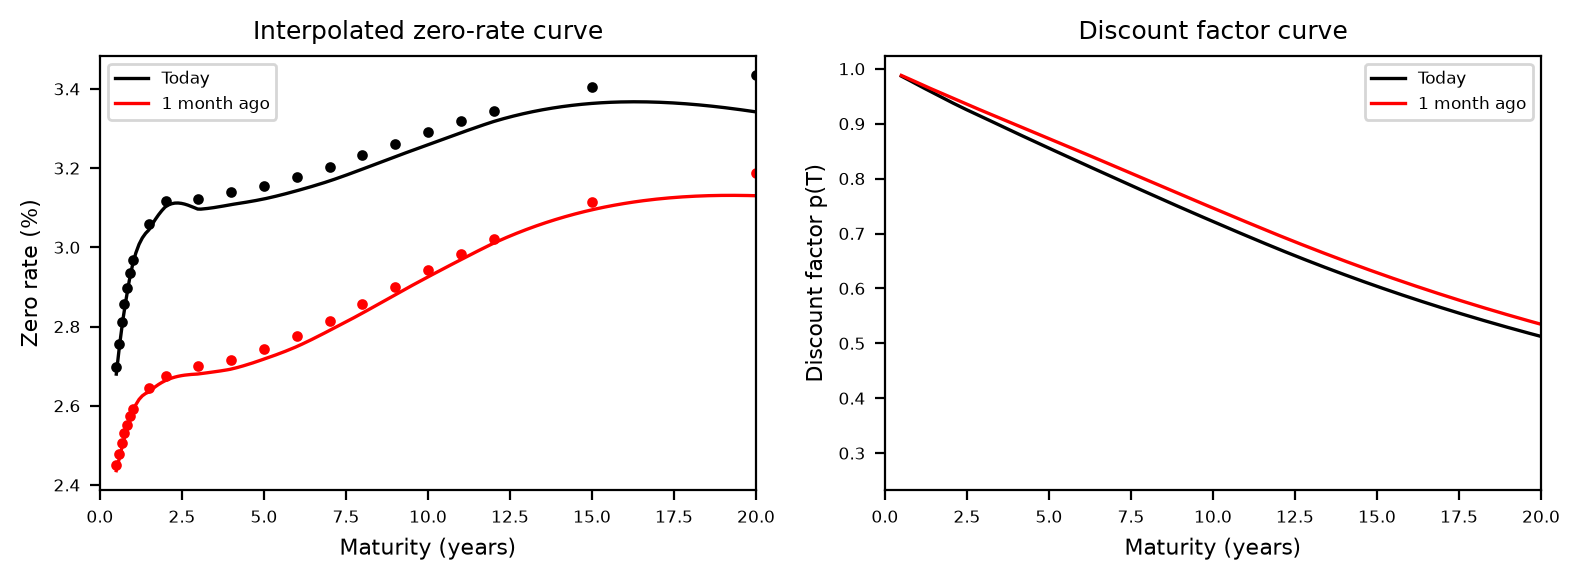

In [8]:
from numpy.polynomial.hermite import hermfit, hermval, hermder
T = np.array([0.5, 0.5833, 0.6667, 0.75, 0.8333, 0.9167, 1.0, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 20, 25, 30, 40, 50])
yield_today = np.array([2.698, 2.757, 2.812, 2.856, 2.898, 2.936, 2.967, 3.058, 3.118, 3.122, 3.139, 3.156, 3.178, 3.203, 3.232, 3.262, 3.290, 3.318, 3.344, 3.406, 3.434, 3.400, 3.338, 3.193, 3.029])/100
yield_1_month_ago = np.array([2.451, 2.478, 2.505, 2.531, 2.552, 2.573, 2.593, 2.646, 2.676, 2.700, 2.716, 2.743, 2.775, 2.815, 2.857, 2.901, 2.943, 2.983, 3.021, 3.115, 3.188, 3.187, 3.152, 3.049, 2.919])/100


# --- build a dense grid for a smooth curve plot ---
T_dense = np.linspace(0.5, 50, 500)

curve_today = build_ois_curve(T_quotes=T, R_quotes=yield_today, T_target=T_dense,
                               interpolation_options={"method": "hermite",  "degree": 3, "transition": None})
curve_month_ago = build_ois_curve(T_quotes=T, R_quotes=yield_1_month_ago, T_target=T_dense,
                                   interpolation_options={"method": "hermite", "degree": 3, "transition": None})

# --- plot: zero-rate curve (left) and discount factor curve (right) ---
fig, axes = plt.subplots(1, 2, dpi=200, figsize=(8,3))

ax = axes[0]
ax.plot(T_dense, curve_today["R_zero_target"]*100, color='black', lw=1.2, label="Today")
ax.plot(T_dense, curve_month_ago["R_zero_target"]*100, color='red', lw=1.2, label="1 month ago")
ax.scatter(T, yield_today*100, s=8, color='black')      # raw PAR rates (for reference)
ax.scatter(T, yield_1_month_ago*100, s=8, color='red')  # raw PAR rates (for reference)
ax.set_xlim(0, 20)
ax.set_xlabel("Maturity (years)", fontsize=8); ax.set_ylabel("Zero rate (%)", fontsize=8)
ax.tick_params(labelsize=6); ax.legend(fontsize=6)
ax.set_title("Interpolated zero-rate curve", fontsize=9)

ax = axes[1]
ax.plot(T_dense, curve_today["p_target"], color='black', lw=1.2, label="Today")
ax.plot(T_dense, curve_month_ago["p_target"], color='red', lw=1.2, label="1 month ago")
ax.set_xlim(0, 20)
ax.set_xlabel("Maturity (years)", fontsize=8); ax.set_ylabel("Discount factor p(T)", fontsize=8)
ax.tick_params(labelsize=6); ax.legend(fontsize=6)
ax.set_title("Discount factor curve", fontsize=9)

plt.tight_layout()
plt.show()

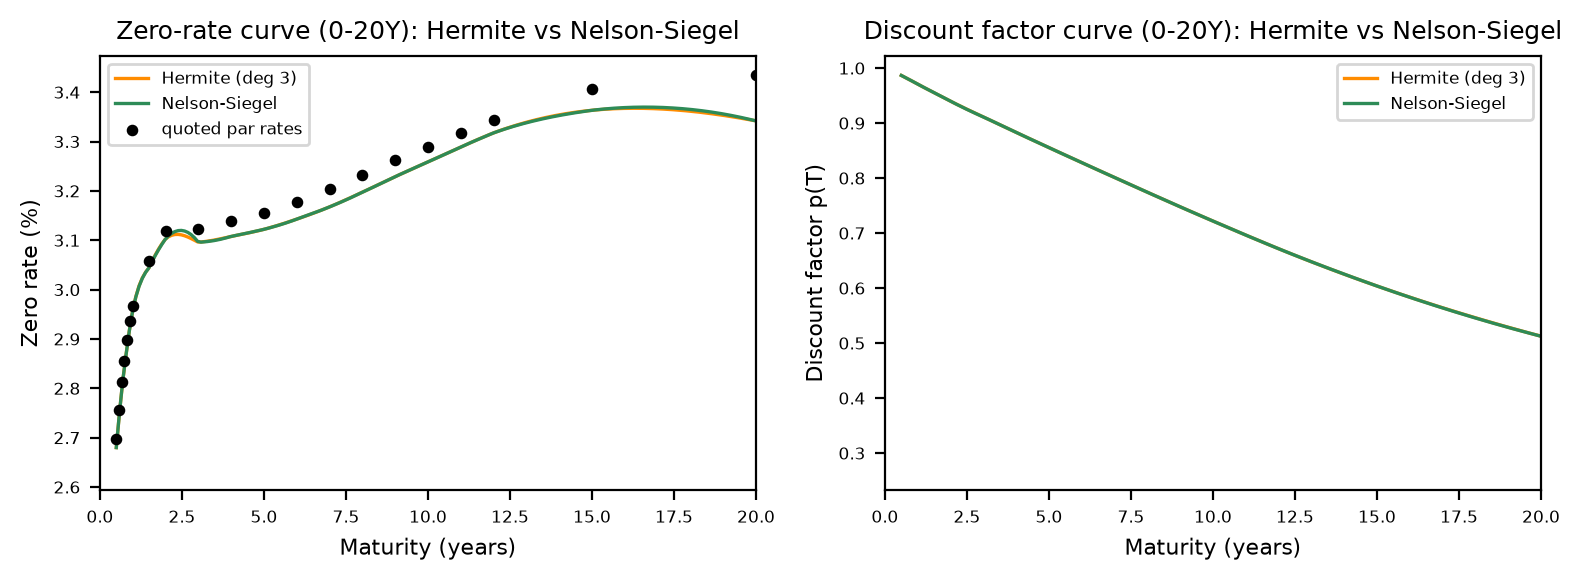

In [9]:
curve_today_herm = build_ois_curve(T_quotes=T, R_quotes=yield_today, T_target=T_dense,
                                    interpolation_options={"method": "hermite", "degree": 3, "transition": None})
curve_today_ns = build_ois_curve(T_quotes=T, R_quotes=yield_today, T_target=T_dense,
                                  interpolation_options={"method": "nelson_siegel", "transition": None})

fig, axes = plt.subplots(1, 2, dpi=200, figsize=(8,3))

ax = axes[0]
ax.plot(T_dense, curve_today_herm["R_zero_target"]*100, color='darkorange', lw=1.2, label="Hermite (deg 3)")
ax.plot(T_dense, curve_today_ns["R_zero_target"]*100, color='seagreen', lw=1.2, label="Nelson-Siegel")
ax.scatter(T, yield_today*100, s=10, color='black', label="quoted par rates", zorder=5)
ax.set_xlim(0, 20)
ax.set_xlabel("Maturity (years)", fontsize=8); ax.set_ylabel("Zero rate (%)", fontsize=8)
ax.tick_params(labelsize=6); ax.legend(fontsize=6)
ax.set_title("Zero-rate curve (0-20Y): Hermite vs Nelson-Siegel", fontsize=9)

ax = axes[1]
ax.plot(T_dense, curve_today_herm["p_target"], color='darkorange', lw=1.2, label="Hermite (deg 3)")
ax.plot(T_dense, curve_today_ns["p_target"], color='seagreen', lw=1.2, label="Nelson-Siegel")
ax.set_xlim(0, 20)
ax.set_xlabel("Maturity (years)", fontsize=8); ax.set_ylabel("Discount factor p(T)", fontsize=8)
ax.tick_params(labelsize=6); ax.legend(fontsize=6)
ax.set_title("Discount factor curve (0-20Y): Hermite vs Nelson-Siegel", fontsize=9)

plt.tight_layout()
plt.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- data pulled from Bloomberg ---
T = np.array([0.5, 0.5833, 0.6667, 0.75, 0.8333, 0.9167, 1.0, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 20, 25, 30, 40, 50])
yield_today = np.array([2.698, 2.757, 2.812, 2.856, 2.898, 2.936, 2.967, 3.058, 3.118, 3.122, 3.139, 3.156, 3.178, 3.203, 3.232, 3.262, 3.290, 3.318, 3.344, 3.406, 3.434, 3.400, 3.338, 3.193, 3.029])/100
yield_1_month_ago = np.array([2.451, 2.478, 2.505, 2.531, 2.552, 2.573, 2.593, 2.646, 2.676, 2.700, 2.716, 2.743, 2.775, 2.815, 2.857, 2.901, 2.943, 2.983, 3.021, 3.115, 3.188, 3.187, 3.152, 3.049, 2.919])/100

offsets_bps = [-200, -100, -50, -25, 0, 25, 50, 100, 200]

atm_5y5y_today = 22.43
spreads_5y5y_today = [9.67, 2.68, 0.95, 0.40, 0.0, -0.26, -0.41, -0.48, -0.09]
iv_market_5y5y_today = (atm_5y5y_today + np.array(spreads_5y5y_today)) / 100

atm_5y5y_month_ago = 21.59
spreads_5y5y_month_ago = [11.53, 3.08, 1.07, 0.44, 0.0, -0.28, -0.43, -0.46, 0.03]
iv_market_5y5y_month_ago = (atm_5y5y_month_ago + np.array(spreads_5y5y_month_ago)) / 100

# --- build OIS curves at annual nodes (alpha=1.0, real EUR convention) ---
T_annual = np.arange(1, 11)   # 1..10

curve_today = build_ois_curve(T_quotes=T, R_quotes=yield_today, T_target=T_annual)
curve_month_ago = build_ois_curve(T_quotes=T, R_quotes=yield_1_month_ago, T_target=T_annual)

# --- 5Y5Y: expiry at T_annual[4]=5, maturity at T_annual[9]=10 ---
idx_exer, idx_mat = 4, 9

rnd_today = swaption_rnd(T_ois=curve_today["T_target"], p_ois=curve_today["p_target"],
                          idx_exer=idx_exer, idx_mat=idx_mat, alpha=1.0,
                          offsets_bps=offsets_bps, iv_market=iv_market_5y5y_today, T_exp=5.0)

rnd_month_ago = swaption_rnd(T_ois=curve_month_ago["T_target"], p_ois=curve_month_ago["p_target"],
                              idx_exer=idx_exer, idx_mat=idx_mat, alpha=1.0,
                              offsets_bps=offsets_bps, iv_market=iv_market_5y5y_month_ago, T_exp=5.0)

print("Today:", rnd_today["R_swap"], rnd_today["S_swap"], rnd_today["sabr_params"])
print("1mo ago:", rnd_month_ago["R_swap"], rnd_month_ago["S_swap"], rnd_month_ago["sabr_params"])

Today: 0.03448434566458005 3.873293625981343 {'sigma_0': np.float64(0.019588739517242878), 'beta': np.float64(0.2918652092808367), 'upsilon': np.float64(0.33956764117661387), 'rho': np.float64(0.16099149679347416)}
1mo ago: 0.03175445966848278 3.9856759993168267 {'sigma_0': np.float64(0.018292099923769203), 'beta': np.float64(0.2995480316083136), 'upsilon': np.float64(0.33565345351482007), 'rho': np.float64(0.1413977117434379)}


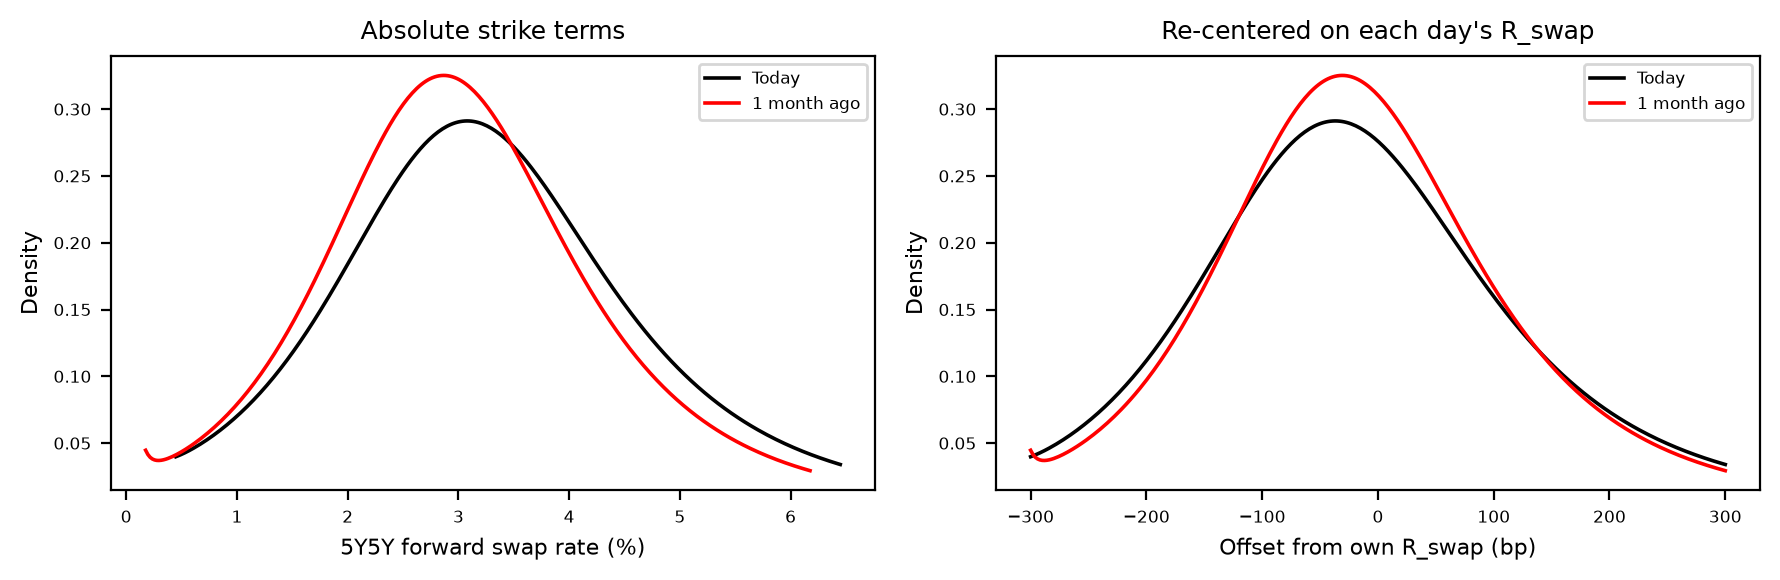

In [17]:
fig, axes = plt.subplots(1, 2, dpi=200, figsize=(9,3))

# --- Panel 1: absolute strike terms ---
ax = axes[0]
ax.plot(rnd_today["K_grid_sabr"]*100, rnd_today["f_sabr"]/100, color='black', lw=1.3, label="Today")
ax.plot(rnd_month_ago["K_grid_sabr"]*100, rnd_month_ago["f_sabr"]/100, color='red', lw=1.3, label="1 month ago")
#ax.axvline(rnd_today["R_swap"]*100, color='black', ls='--', lw=0.7)
#ax.axvline(rnd_month_ago["R_swap"]*100, color='red', ls='--', lw=0.7)
ax.set_xlabel("5Y5Y forward swap rate (%)", fontsize=8)
ax.set_ylabel("Density", fontsize=8)
ax.set_title("Absolute strike terms", fontsize=9)
ax.tick_params(labelsize=6)
ax.legend(fontsize=6)

# --- Panel 2: strike-OFFSET terms, centered on each day's own R_swap ---
ax = axes[1]
offset_today = (rnd_today["K_grid_sabr"] - rnd_today["R_swap"])*10000       # in bp
offset_month_ago = (rnd_month_ago["K_grid_sabr"] - rnd_month_ago["R_swap"])*10000
ax.plot(offset_today, rnd_today["f_sabr"]/100, color='black', lw=1.3, label="Today")
ax.plot(offset_month_ago, rnd_month_ago["f_sabr"]/100, color='red', lw=1.3, label="1 month ago")
#ax.axvline(0, color='grey', ls='--', lw=0.7)
ax.set_xlabel("Offset from own R_swap (bp)", fontsize=8)
ax.set_ylabel("Density", fontsize=8)
ax.set_title("Re-centered on each day's R_swap", fontsize=9)
ax.tick_params(labelsize=6)
ax.legend(fontsize=6)

plt.tight_layout()
plt.show()

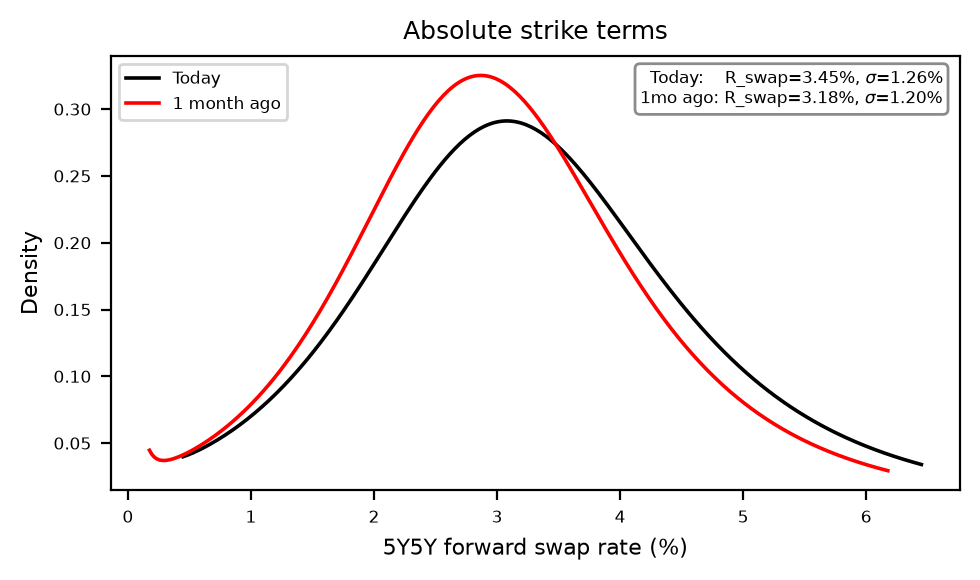

In [14]:
fig, ax = plt.subplots(dpi=200, figsize=(5,3))
ax.plot(rnd_today["K_grid_sabr"]*100, rnd_today["f_sabr"]/100, color='black', lw=1.3, label="Today")
ax.plot(rnd_month_ago["K_grid_sabr"]*100, rnd_month_ago["f_sabr"]/100, color='red', lw=1.3, label="1 month ago")
ax.set_xlabel("5Y5Y forward swap rate (%)", fontsize=8)
ax.set_ylabel("Density", fontsize=8)
ax.set_title("Absolute strike terms", fontsize=9)
ax.tick_params(labelsize=6)
ax.legend(fontsize=6, loc='upper left')

textstr = (f"Today:    R_swap={rnd_today['R_swap']*100:.2f}%, $\\sigma$={std_today*100:.2f}%\n"
           f"1mo ago: R_swap={rnd_month_ago['R_swap']*100:.2f}%, $\\sigma$={std_month_ago*100:.2f}%")
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=6,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='grey', alpha=0.9))

plt.tight_layout()
plt.show()

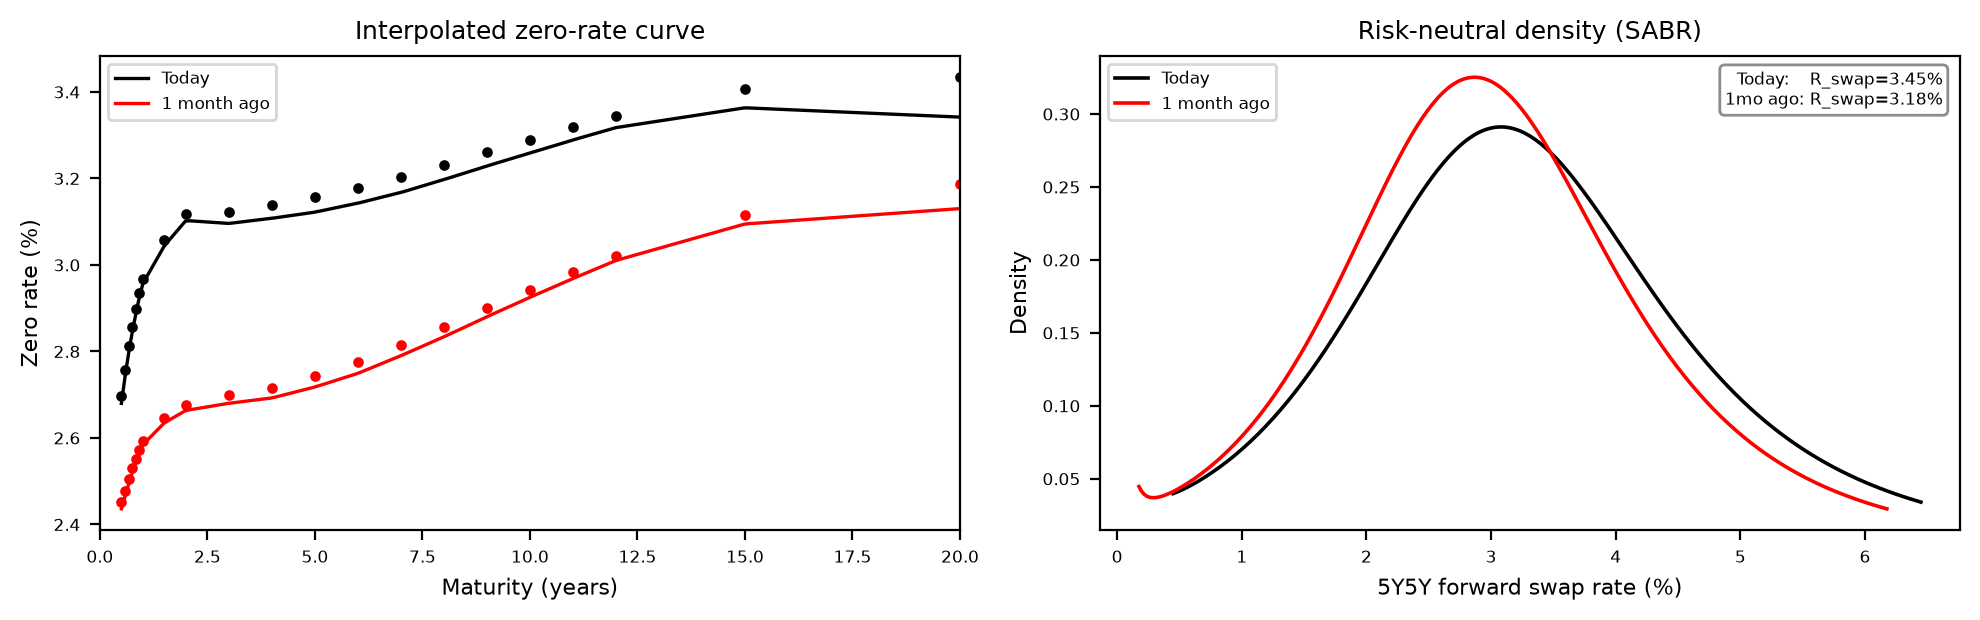

In [19]:
# dedicated dense curve, just for this plot -- doesn't touch curve_today/curve_month_ago
curve_today_dense = build_ois_curve(T_quotes=T, R_quotes=yield_today, T_target=T_dense)
curve_month_ago_dense = build_ois_curve(T_quotes=T, R_quotes=yield_1_month_ago, T_target=T_dense)

fig, axes = plt.subplots(1, 2, dpi=200, figsize=(10,3.2))

ax = axes[0]
ax.plot(T_dense, curve_today_dense["R_zero_target"]*100, color='black', lw=1.2, label="Today")
ax.plot(T_dense, curve_month_ago_dense["R_zero_target"]*100, color='red', lw=1.2, label="1 month ago")
ax.scatter(T, yield_today*100, s=8, color='black')
ax.scatter(T, yield_1_month_ago*100, s=8, color='red')
ax.set_xlim(0, 20)
ax.set_xlabel("Maturity (years)", fontsize=8); ax.set_ylabel("Zero rate (%)", fontsize=8)
ax.tick_params(labelsize=6); ax.legend(fontsize=6)
ax.set_title("Interpolated zero-rate curve", fontsize=9)

ax = axes[1]
ax.plot(rnd_today["K_grid_sabr"]*100, rnd_today["f_sabr"]/100, color='black', lw=1.3, label="Today")
ax.plot(rnd_month_ago["K_grid_sabr"]*100, rnd_month_ago["f_sabr"]/100, color='red', lw=1.3, label="1 month ago")
ax.set_xlabel("5Y5Y forward swap rate (%)", fontsize=8)
ax.set_ylabel("Density", fontsize=8)
ax.set_title("Risk-neutral density (SABR)", fontsize=9)
ax.tick_params(labelsize=6)
ax.legend(fontsize=6, loc='upper left')

textstr = (f"Today:    R_swap={rnd_today['R_swap']*100:.2f}%\n"
           f"1mo ago: R_swap={rnd_month_ago['R_swap']*100:.2f}%")
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=6,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='grey', alpha=0.9))

plt.tight_layout()
plt.show()